       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1      Full-time    

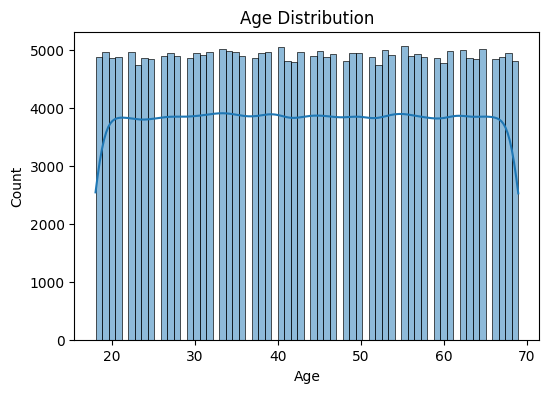

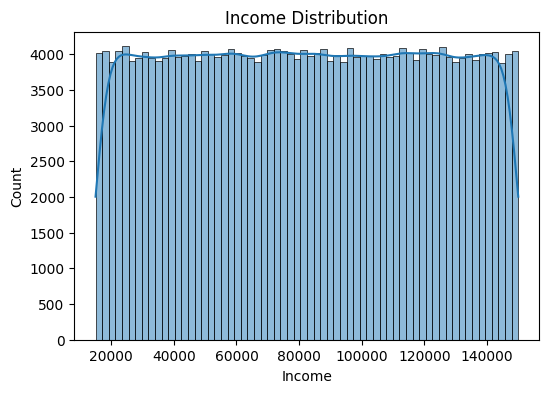

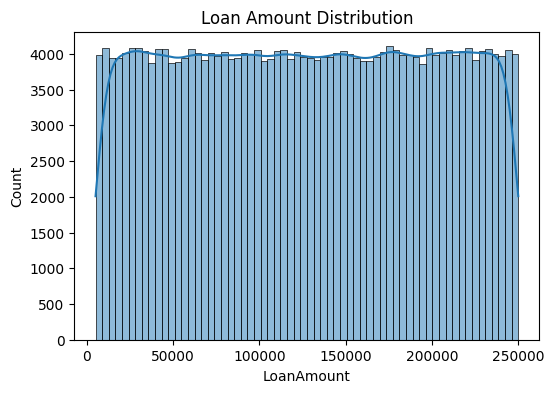

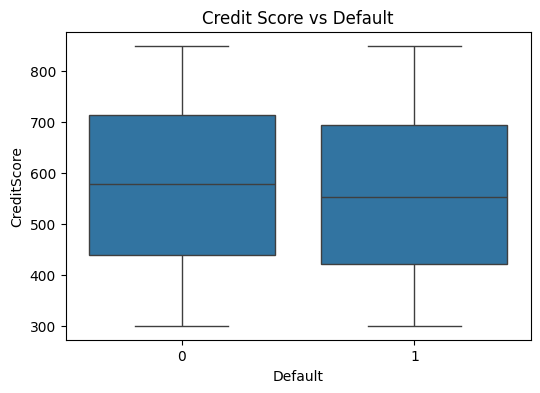

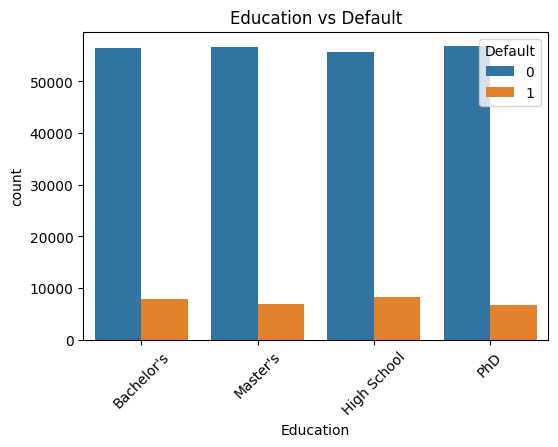

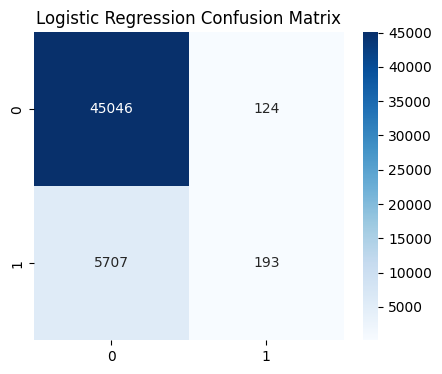

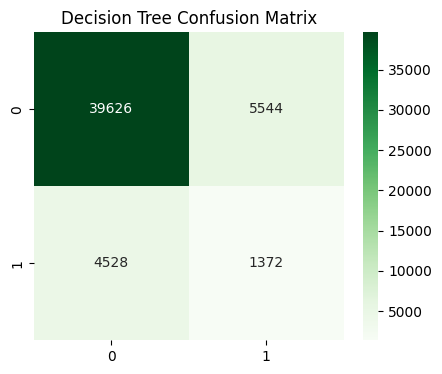


=== Logistic Regression ===
Accuracy: 0.885823379674956
MAE: 0.11417662032504405
RMSE: 0.3379003112236567

=== Decision Tree ===
Accuracy: 0.8027804973565694
MAE: 0.19721950264343058
RMSE: 0.4440940245527185


In [ ]:

# -----------------------------
## Introduction
# -----------------------------
# This project focuses on predicting whether a loan applicant will default or not using machine learning models. 
# The goal is to analyze financial and personal data to build a classification system for credit risk assessment.

# -----------------------------
## Problem Statement
# -----------------------------
# The objective is to predict loan default using classification models such as Logistic Regression 
# and Decision Tree based on applicant financial and demographic information.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------------------------------------
## Dataset Description and Loading
# ---------------------------------------------
# The dataset contains financial and personal information of loan applicants.
# It includes features such as:
# - Age, Income, Loan Amount, Credit Score
# - Employment and marital details
# - Loan purpose and financial ratios
# - Target variable: Default (0 = No Default, 1 = Default)

# The dataset is used for binary classification to predict credit risk.

df = pd.read_csv("loan_default.csv")

print(df.head())
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

# -----------------------------
# Data Cleaning
# -----------------------------
print("\n=== Missing values before:\n", df.isnull().sum())

# Fill numeric missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n=== Missing values after:\n", df.isnull().sum())

# -----------------------------
# Data Visualization
# -----------------------------
## Exploratory Data Analysis (EDA)
# We visualize key features to understand data distribution and relationships.

# -----------------------------
# Histogram: Data Distribution
# -----------------------------
# Used to understand how values are distributed
# and whether the data is skewed or normally distributed.

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

# -----------------------------
# Box Plot: Credit Score vs Default
# -----------------------------
# This plot shows how credit scores differ between defaulters and non-defaulters.

plt.figure(figsize=(6,4))
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score vs Default")
plt.show()

# -----------------------------
# Count Plot: Education vs Default
# -----------------------------
# This plot shows the distribution of loan default across different education levels.
# Categorical features like education can reveal behavioral patterns in default risk.

plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Default', data=df)
plt.title("Education vs Default")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# Data Preprocessing
# -----------------------------

# Remove ID column (not useful for ML)
df = df.drop('LoanID', axis=1)

# Encode categorical features
cat_features = [
    'Education', 'EmploymentType', 'MaritalStatus',
    'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner'
]

df = pd.get_dummies(df, columns=cat_features, drop_first=True)

# Split features and target
X = df.drop('Default', axis=1)
y = df['Default']

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


# -----------------------------
## Model Training and Testing
# We trained two classification models:
# - Logistic Regression
# - Decision Tree Classifier
# -----------------------------

# =========================================================
# MODEL 1: LOGISTIC REGRESSION
# =========================================================

lr_model = LogisticRegression(max_iter=2000, solver='saga')
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_cm = confusion_matrix(y_test, lr_pred)
mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

plt.figure(figsize=(5,4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# =========================================================
# MODEL 2: DECISION TREE
# =========================================================

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_cm = confusion_matrix(y_test, dt_pred)
mae = mean_absolute_error(y_test, dt_pred)
rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
plt.figure(figsize=(5,4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()


# -----------------------------
# Model Evaluation Metrics
# -----------------------------

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))


print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))

# -----------------------------
## Conclusion
# -----------------------------
# In this project, we developed a credit risk prediction system using two models:
# Logistic Regression and Decision Tree.

# Logistic Regression performed better with an accuracy of ~88.6%,
# while Decision Tree achieved ~80.3% accuracy.

# Error metrics further support this:
# - Logistic Regression has lower MAE (0.114) and RMSE (0.338)
# - Decision Tree has higher MAE (0.197) and RMSE (0.444)
# This indicates that Logistic Regression makes fewer prediction errors overall.
# Overall, Logistic Regression is the better model for this dataset, providing more accurate predictions for credit risk assessment.